In [1]:
import random
import gym
import numpy as np
import collections
from tqdm import tqdm
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import rl_utils

# Replay Buffer

In [2]:
class ReplayBuffer:
    ''' 经验回放池 '''
    def __init__(self, capacity):
        self.buffer = collections.deque(maxlen=capacity)  # 队列,先进先出

    def add(self, state, action, reward, next_state, done):  # 将数据加入buffer
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):  # 从buffer中采样数据,数量为batch_size
        transitions = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*transitions)
        return np.array(state), action, reward, np.array(next_state), done

    def size(self):  # 目前buffer中数据的数量
        return len(self.buffer)

Collection.deque:

https://docs.python.org/3/library/collections.html#collections.deque

append; appendleft, clear, copy, count, extend, extendleft

pop; popleft; remove(value); reverse(); rotate(n = 1); maxlen


Random.sample

Syntax : random.sample(sequence, k)

Parameters:

sequence: Can be a list, tuple, string, or set.

k: An Integer value, it specify the length of a sample.

Returns: k length new list of elements chosen from the sequence.

In [3]:
import random 
  
  
# Prints list of random items of 
# length 3 from the given list. 
list1 = [1, 2, 3, 4, 5, 6]  
print("With list:", random.sample(list1, 3)) 
  
# Prints list of random items of 
# length 4 from the given string.  
string = "GeeksforGeeks"
print("With string:", random.sample(string, 4)) 
  
# Prints list of random items of 
# length 4 from the given tuple. 
tuple1 = ("ankit", "geeks", "computer", "science", 
                   "portal", "scientist", "btech") 
print("With tuple:", random.sample(tuple1, 4)) 
  
  
# Prints list of random items of 
# length 3 from the given set. 
set1 = {"a", "b", "c", "d", "e"} 
print("With set:", random.sample(set1, 3)) 

With list: [1, 2, 3]
With string: ['k', 'r', 'e', 'k']
With tuple: ['science', 'computer', 'geeks', 'ankit']
With set: ['a', 'd', 'e']


Definition and Usage


The zip() function returns a zip object, which is an iterator of tuples where the first item in each passed iterator is paired together, and then the second item in each passed iterator are paired together etc.

If the passed iterables have different lengths, the iterable with the least items decides the length of the new iterator.

Syntax

zip(iterator1, iterator2, iterator3 ...)

Parameter Values

Parameter	Description

iterable1, iterable2, iterable3 ...	Iterable objects that will be joined together

In [4]:
a = ("John", "Charles", "Mike")
b = ("Jenny", "Christy", "Monica", "lll")
# If one tuple contains more items, these items are ignored
x = zip(a, b)
print(tuple(x))

(('John', 'Jenny'), ('Charles', 'Christy'), ('Mike', 'Monica'))


# Qnet with one hidden layer

In [5]:
class Qnet(torch.nn.Module):
    ''' 只有一层隐藏层的Q网络 '''
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(Qnet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))  # 隐藏层使用ReLU激活函数
        return self.fc2(x)

torch.nn.Module

https://pytorch.org/docs/stable/generated/torch.nn.Module.html

https://www.bilibili.com/video/BV1hE411t7RN?p=16&vd_source=4cca6f0dd2495280b5f065c0e86f221c


forward(*input):

Defines the computation performed at every call.

Should be overridden by all subclasses.



In [6]:
class Model(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = torch.nn.Conv2d(1, 20, 5)
        self.conv2 = torch.nn.Conv2d(20, 20, 5)

    def forward(self, x):# input --> forward --> output
        x = F.relu(self.conv1(x))
        return F.relu(self.conv2(x))
       # x -> conv->relu->conv->relu  ->output
       
class tryout(torch.nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, input):
        output = input + 1
        return output
 

_try = tryout()
print(_try(3))


4


# DQN

In [7]:
class DQN:
    ''' DQN算法 '''
    def __init__(self, state_dim, hidden_dim, action_dim, learning_rate, gamma,
                 epsilon, target_update, device):
        self.action_dim = action_dim
        self.q_net = Qnet(state_dim, hidden_dim, self.action_dim).to(device)  # Q网络
        # 目标网络
        self.target_q_net = Qnet(state_dim, hidden_dim, self.action_dim).to(device)
        # 使用Adam优化器
        self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr=learning_rate)
        self.gamma = gamma  # 折扣因子
        self.epsilon = epsilon  # epsilon-贪婪策略
        self.target_update = target_update  # 目标网络更新频率
        self.count = 0  # 计数器,记录更新次数
        self.device = device

    def take_action(self, state):  # epsilon-贪婪策略采取动作
        if np.random.random() < self.epsilon:
            action = np.random.randint(self.action_dim)
        else:
            state = torch.tensor([state], dtype=torch.float).to(self.device)
            action = self.q_net(state).argmax().item()
            # https://pytorch.org/docs/1.2.0/tensors.html#torch.Tensor.item
        return action

    def update(self, transition_dict):
        states = torch.tensor(transition_dict['states'], dtype=torch.float).view(-1, 4).to(self.device)
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'], dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'], dtype=torch.float).view(-1, 4).to(self.device)
        dones = torch.tensor(transition_dict['dones'], dtype=torch.float).view(-1, 1).to(self.device)

        q_values = self.q_net(states).gather(1, actions)  # Q值 by row
        
        # 下个状态的最大Q值 
        max_next_q_values = self.target_q_net(next_states).max(1)[0].view(-1, 1) # tensor max
        q_targets = rewards + self.gamma * max_next_q_values * (1 - dones)  # TD误差目标
        dqn_loss = torch.mean(F.mse_loss(q_values, q_targets))  # 均方误差损失函数

        self.optimizer.zero_grad()  # PyTorch中默认梯度会累积,这里需要显式将梯度置为0
        dqn_loss.backward()  # 反向传播更新参数
        self.optimizer.step() #one step gradient descent

        if self.count % self.target_update == 0:
            self.target_q_net.load_state_dict(
                self.q_net.state_dict())  # 更新目标网络
            
        
        self.count += 1 # total updates

https://pytorch.org/docs/0.3.1/tensors.html#torch.Tensor.max

y.max(1) takes the max over dimension 1 and returns two values. an example would help.

Supposing we have a tensor y of shape (3, 4) containing

 0.6857  0.1098  0.4687  0.7822

 0.4170  0.2476  0.1339  0.5563

 0.9425  0.8433  0.1335  0.3169

y.max(1) returns two tensors…

 1. the max value in each row of y

    0.7822

    0.5563

    0.9425

 2. the column index at which the max value is found.
    3

    3

    0



torch.gather(input, dim, index, *, sparse_grad=False, out=None) → Tensor

https://pytorch.org/docs/stable/generated/torch.gather.html


Parameters:

input (Tensor) – the source tensor

dim (int) – the axis along which to index

index (LongTensor) – the indices of elements to gather

Keyword Arguments:

sparse_grad (bool, optional) – If True, gradient w.r.t. input will be a sparse tensor.

out (Tensor, optional) – the destination tensor

In [8]:
t = torch.tensor([[1, 2], [3, 4]])
print(t.gather( 0, torch.tensor([[0, 0], [1, 0]])))
# 0: BY COL
# 1: BY ROW
# 1, 2
# 3, 4

# 0, 0
# 1, 0
print(t.gather(1, torch.tensor([[0, 0], [1, 0]])))


tensor([[1, 2],
        [3, 2]])
tensor([[1, 1],
        [4, 3]])


https://pytorch.org/docs/1.2.0/tensors.html#torch.Tensor.item
item() → number

Returns the value of this tensor as a standard Python number. This only works for tensors with one element. For other cases, see tolist().

This operation is not differentiable.

Example:

>>> x = torch.tensor([1.0])

>>> x.item()

1.0


https://pytorch.org/docs/stable/generated/torch.Tensor.view.html

>>> x = torch.randn(4, 4)

>>> x.size()

torch.Size([4, 4])

>>> y = x.view(16)

>>> y.size()

torch.Size([16])

>>> z = x.view(-1, 8)  # the size -1 is inferred from other dimensions

>>> z.size()

torch.Size([2, 8])

>>> a = torch.randn(1, 2, 3, 4)

>>> a.size()

torch.Size([1, 2, 3, 4])

>>> b = a.transpose(1, 2)  # Swaps 2nd and 3rd dimension

>>> b.size()

torch.Size([1, 3, 2, 4])

>>> c = a.view(1, 3, 2, 4)  # Does not change tensor layout in memory

>>> c.size()

torch.Size([1, 3, 2, 4])

>>> torch.equal(b, c)

False

In [9]:
lr = 2e-3 # learning rate
num_episodes = 500
hidden_dim = 128
gamma = 0.98
epsilon = 0.01
target_update = 10 
buffer_size = 10000 # totoal size
minimal_size = 500 # start training nn
batch_size = 64
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

env_name = 'CartPole-v0'
env = gym.make(env_name)
random.seed(0)
np.random.seed(0)
env.seed(0)
torch.manual_seed(0)
replay_buffer = ReplayBuffer(buffer_size)# set up a buffer
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n #action space
agent = DQN(state_dim, hidden_dim, action_dim, lr, gamma, epsilon, target_update, device)

return_list = []
for i in range(10):
    with tqdm(total=int(num_episodes / 10), desc='Iteration %d' % i) as pbar:
        for i_episode in range(int(num_episodes / 10)):
            episode_return = 0
            state = env.reset()
            done = False
            while not done:
                action = agent.take_action(state)
                next_state, reward, done, _ = env.step(action)
                replay_buffer.add(state, action, reward, next_state, done)
                state = next_state
                episode_return += reward
                # 当buffer数据的数量超过一定值后,才进行Q网络训练
                if replay_buffer.size() > minimal_size:
                    b_s, b_a, b_r, b_ns, b_d = replay_buffer.sample(batch_size)
                    transition_dict = {
                        'states': b_s,
                        'actions': b_a,
                        'next_states': b_ns,
                        'rewards': b_r,
                        'dones': b_d
                    }
                    agent.update(transition_dict)
            return_list.append(episode_return)
            if (i_episode + 1) % 10 == 0:
                pbar.set_postfix({
                    'episode':
                    '%d' % (num_episodes / 10 * i + i_episode + 1),
                    'return':
                    '%.3f' % np.mean(return_list[-10:])
                })
            pbar.update(1)

# Iteration 0: 100%|██████████| 50/50 [00:00<00:00, 764.86it/s, episode=50,
# return=9.300]
# Iteration 1: 100%|██████████| 50/50 [00:04<00:00, 10.66it/s, episode=100,
# return=12.300]
# Iteration 2: 100%|██████████| 50/50 [00:24<00:00,  2.05it/s, episode=150,
# return=123.000]
# Iteration 3: 100%|██████████| 50/50 [01:25<00:00,  1.71s/it, episode=200,
# return=153.600]
# Iteration 4: 100%|██████████| 50/50 [01:30<00:00,  1.80s/it, episode=250,
# return=180.500]
# Iteration 5: 100%|██████████| 50/50 [01:24<00:00,  1.68s/it, episode=300,
# return=185.000]
# Iteration 6: 100%|██████████| 50/50 [01:32<00:00,  1.85s/it, episode=350,
# return=193.900]
# Iteration 7: 100%|██████████| 50/50 [01:31<00:00,  1.84s/it, episode=400,
# return=196.600]
# Iteration 8: 100%|██████████| 50/50 [01:33<00:00,  1.88s/it, episode=450,
# return=193.800]
# Iteration 9: 100%|██████████| 50/50 [01:34<00:00,  1.88s/it, episode=500,
# return=200.000]

Iteration 0:   0%|          | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_3450/797754674.py:21: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:261.)
  state = torch.tensor([state], dtype=torch.float).to(self.device)
Iteration 9: 100%|██████████| 50/50 [00:39<00:00,  1.27it/s, episode=500, return=200.000]


In [18]:
env.observation_space
env.observation_space.shape

Box(-3.4028234663852886e+38, 3.4028234663852886e+38, (4,), float32)


state_dim

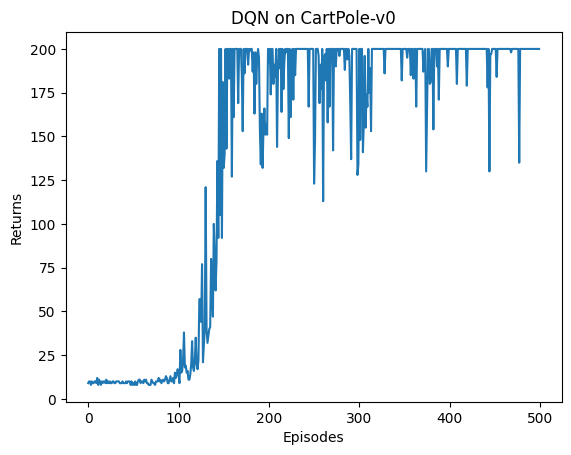

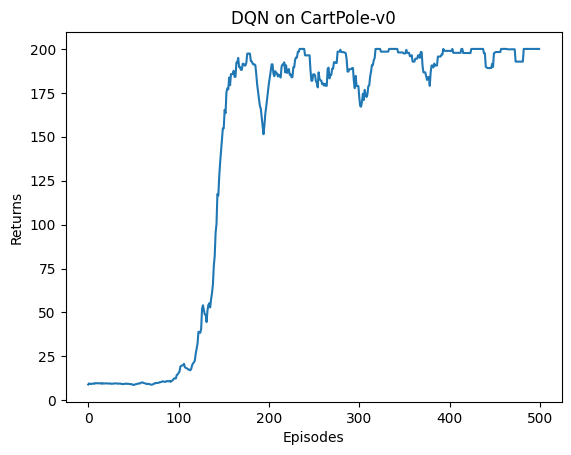

In [41]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DQN on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DQN on {}'.format(env_name))
plt.show()

In [ ]:
class ConvolutionalQnet(torch.nn.Module):
    ''' 加入卷积层的Q网络 '''
    def __init__(self, action_dim, in_channels=4):
        super(ConvolutionalQnet, self).__init__()
        self.conv1 = torch.nn.Conv2d(in_channels, 32, kernel_size=8, stride=4)
        self.conv2 = torch.nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = torch.nn.Conv2d(64, 64, kernel_size=3, stride=1)
        self.fc4 = torch.nn.Linear(7 * 7 * 64, 512)
        self.head = torch.nn.Linear(512, action_dim)

    def forward(self, x):
        x = x / 255
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.fc4(x))
        return self.head(x)